In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve, precision_recall_curve
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [4]:
## 2. Data Loading & Exploration

In [5]:
# Load dataset
df = pd.read_csv('278k_labelled_uri.csv')

print("Dataset Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nFirst few rows:")
print(df.head())

Dataset Shape: (277938, 15)

Column Names: ['Unnamed: 0.1', 'Unnamed: 0', 'duration (ms)', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'spec_rate', 'labels', 'uri']

First few rows:
   Unnamed: 0.1  Unnamed: 0  duration (ms)  danceability  energy  loudness  \
0             0           0       195000.0         0.611   0.614    -8.815   
1             1           1       194641.0         0.638   0.781    -6.848   
2             2           2       217573.0         0.560   0.810    -8.029   
3             3           3       443478.0         0.525   0.699    -4.571   
4             4           4       225862.0         0.367   0.771    -5.863   

   speechiness  acousticness  instrumentalness  liveness  valence    tempo  \
0       0.0672        0.0169          0.000794    0.7530    0.520  128.050   
1       0.0285        0.0118          0.009530    0.3490    0.250  122.985   
2       0.0872        0.0071          

In [6]:
# Check for missing values and data info
print("Missing Values:")
print(df.isnull().sum())
print("\nData Info:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())

Missing Values:
Unnamed: 0.1        0
Unnamed: 0          0
duration (ms)       0
danceability        0
energy              0
loudness            0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
spec_rate           0
labels              0
uri                 0
dtype: int64

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277938 entries, 0 to 277937
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0.1      277938 non-null  int64  
 1   Unnamed: 0        277938 non-null  int64  
 2   duration (ms)     277938 non-null  float64
 3   danceability      277938 non-null  float64
 4   energy            277938 non-null  float64
 5   loudness          277938 non-null  float64
 6   speechiness       277938 non-null  float64
 7   acousticness      277938 non-null  float64
 8   instrumentalness  277938 non-null

Label Distribution:
labels
0     82058
1    106429
2     47065
3     42386
Name: count, dtype: int64

Label Percentages:
labels
0    29.52
1    38.29
2    16.93
3    15.25
Name: count, dtype: float64


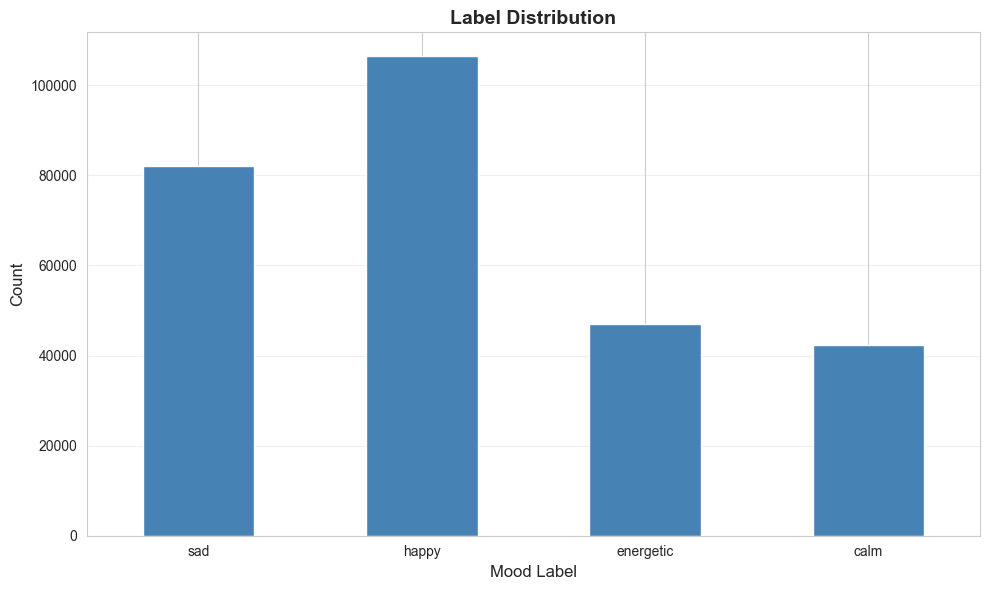

In [7]:
# Label distribution
label_map = {0: 'sad', 1: 'happy', 2: 'energetic', 3: 'calm'}

print("Label Distribution:")
label_counts = df['labels'].value_counts().sort_index()
print(label_counts)
print("\nLabel Percentages:")
print((label_counts / len(df) * 100).round(2))

# Visualize label distribution
plt.figure(figsize=(10, 6))
label_counts.plot(kind='bar', color='steelblue')
plt.title('Label Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Mood Label', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(range(4), [label_map[i] for i in range(4)], rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

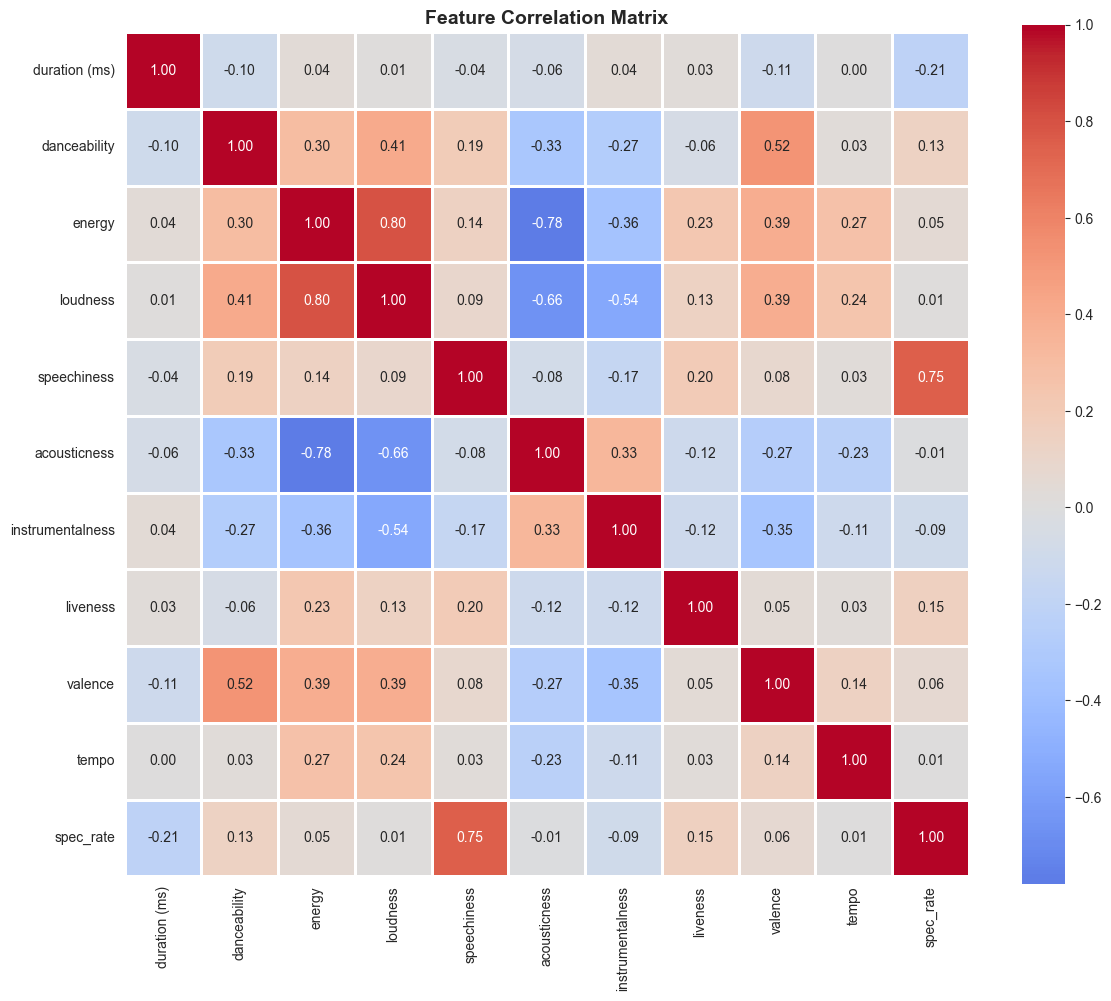

In [8]:
# Feature correlation heatmap
feature_cols = [
    'duration (ms)', 'danceability', 'energy', 'loudness', 
    'speechiness', 'acousticness', 'instrumentalness', 
    'liveness', 'valence', 'tempo', 'spec_rate'
]

plt.figure(figsize=(12, 10))
corr = df[feature_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=1)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
## 3. Feature Engineering & Preprocessing

In [22]:
# Extract features and labels
X = df[feature_cols].copy()
y = df['labels'].values

# Handle missing values
if X.isnull().sum().sum() > 0:
    print("Filling missing values...")
    X = X.fillna(X.median())

# Feature engineering
X_processed = X.copy()

# Convert duration from ms to seconds
X_processed['duration_sec'] = X['duration (ms)'] / 1000.0

# # Create interaction features
# X_processed['energy_valence'] = X['energy'] * X['valence']
# X_processed['danceability_energy'] = X['danceability'] * X['energy']
# X_processed['acousticness_instrumentalness'] = X['acousticness'] * X['instrumentalness']

# Remove original columns we transformed
X_processed = X_processed.drop(['duration (ms)', 'spec_rate'], axis=1)

feature_cols_processed = list(X_processed.columns)
print(f"\nProcessed features: {len(feature_cols_processed)}")
print(f"Feature names: {feature_cols_processed}")
print(f"Feature shapes: X={X_processed.shape}, y={y.shape}")


Processed features: 10
Feature names: ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_sec']
Feature shapes: X=(277938, 10), y=(277938,)


In [11]:
## 4. Data Splitting & Scaling

In [23]:
# Train/Validation/Test split (70/15/15)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_processed, y, test_size=0.15, random_state=RANDOM_SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=RANDOM_SEED, stratify=y_temp  # 0.176 ≈ 15/85
)

print(f"Train: {X_train.shape[0]} samples")
print(f"Validation: {X_val.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")
print(f"\nTrain label distribution:")
print(pd.Series(y_train).value_counts().sort_index())

Train: 194667 samples
Validation: 41580 samples
Test: 41691 samples

Train label distribution:
0    57473
1    74543
2    32964
3    29687
Name: count, dtype: int64


In [24]:
# Scale features using RobustScaler (less sensitive to outliers)
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully")
print(f"Train shape: {X_train_scaled.shape}")
print(f"Mean: {X_train_scaled.mean(axis=0)[:5]}")
print(f"Std: {X_train_scaled.std(axis=0)[:5]}")

Features scaled successfully
Train shape: (194667, 10)
Mean: [-0.06949496 -0.07711154 -0.28571222  0.87692871  0.17255715]
Std: [0.72300953 0.62122971 0.96903663 2.41888089 0.50560566]


In [14]:
## 5. Baseline Models (Scikit-learn)

In [25]:
# Dictionary to store results
results = {}

def evaluate_model(model, X_train, y_train, X_val, y_val, model_name):
    """Evaluate a model and return metrics"""
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    
    # Metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred, average='weighted')
    val_precision = precision_score(y_val, y_val_pred, average='weighted')
    val_recall = recall_score(y_val, y_val_pred, average='weighted')
    
    result = {
        'model': model_name,
        'train_accuracy': train_acc,
        'val_accuracy': val_acc,
        'val_f1': val_f1,
        'val_precision': val_precision,
        'val_recall': val_recall
    }
    
    return result, y_val_pred, model

In [ ]:
# 1. Logistic Regression
print("Training Logistic Regression...")
lr = LogisticRegression(random_state=RANDOM_SEED, max_iter=1000, multi_class='multinomial', n_jobs=-1)
result, y_val_pred_lr, model_lr = evaluate_model(lr, X_train_scaled, y_train, X_val_scaled, y_val, "Logistic Regression")
results['Logistic Regression'] = result
print(f"Validation Accuracy: {result['val_accuracy']:.4f}")
print(f"Validation F1: {result['val_f1']:.4f}")

In [26]:
# 2. Random Forest
print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1, verbose=0)
result, y_val_pred_rf, model_rf = evaluate_model(rf, X_train_scaled, y_train, X_val_scaled, y_val, "Random Forest")
results['Random Forest'] = result
print(f"Validation Accuracy: {result['val_accuracy']:.4f}")
print(f"Validation F1: {result['val_f1']:.4f}")

Training Random Forest...
Validation Accuracy: 0.9385
Validation F1: 0.9384


In [ ]:
# 3. Gradient Boosting
print("Training Gradient Boosting...")
gb = GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_SEED, verbose=0)
result, y_val_pred_gb, model_gb = evaluate_model(gb, X_train_scaled, y_train, X_val_scaled, y_val, "Gradient Boosting")
results['Gradient Boosting'] = result
print(f"Validation Accuracy: {result['val_accuracy']:.4f}")
print(f"Validation F1: {result['val_f1']:.4f}")

In [ ]:
# 4. Support Vector Machine
print("Training SVM...")
svm = SVC(kernel='rbf', random_state=RANDOM_SEED, probability=True, verbose=False)
result, y_val_pred_svm, model_svm = evaluate_model(svm, X_train_scaled, y_train, X_val_scaled, y_val, "SVM")
results['SVM'] = result
print(f"Validation Accuracy: {result['val_accuracy']:.4f}")
print(f"Validation F1: {result['val_f1']:.4f}")

Training SVM...


In [ ]:
# 5. Multi-layer Perceptron (Scikit-learn)
print("Training MLP...")
mlp_sklearn = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500, random_state=RANDOM_SEED, verbose=False)
result, y_val_pred_mlp, model_mlp = evaluate_model(mlp_sklearn, X_train_scaled, y_train, X_val_scaled, y_val, "MLP (sklearn)")
results['MLP (sklearn)'] = result
print(f"Validation Accuracy: {result['val_accuracy']:.4f}")
print(f"Validation F1: {result['val_f1']:.4f}")

In [ ]:
# Compare baseline models
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('val_accuracy', ascending=False)
print("\nBaseline Model Comparison:")
print(results_df.to_string())

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_df[['train_accuracy', 'val_accuracy']].plot(kind='bar', ax=axes[0], color=['skyblue', 'coral'])
axes[0].set_title('Train vs Validation Accuracy', fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].set_xlabel('Model')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

results_df[['val_accuracy', 'val_f1']].plot(kind='bar', ax=axes[1], color=['steelblue', 'orange'])
axes[1].set_title('Validation Accuracy vs F1 Score', fontweight='bold')
axes[1].set_ylabel('Score')
axes[1].set_xlabel('Model')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
## 6. PyTorch Neural Network Models

In [ ]:
# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.LongTensor(y_train)
X_val_tensor = torch.FloatTensor(X_val_scaled)
y_val_tensor = torch.LongTensor(y_val)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.LongTensor(y_test)

# Create DataLoaders
batch_size = 256
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Input dimension: {X_train_scaled.shape[1]}")
print(f"Number of classes: {len(np.unique(y))}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

In [ ]:
# Define PyTorch model
class MoodClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dims, num_classes=4, dropout=0.3):
        super(MoodClassifier, self).__init__()
        
        layers = []
        current_dim = input_dim
        
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(current_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            current_dim = hidden_dim
        
        # Output layer
        layers.append(nn.Linear(current_dim, num_classes))
        
        self.mlp = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.mlp(x)

# Model configurations to try
model_configs = [
    {'name': 'MLP-Small', 'hidden_dims': [64, 32], 'dropout': 0.3},
    {'name': 'MLP-Medium', 'hidden_dims': [128, 64, 32], 'dropout': 0.3},
    {'name': 'MLP-Large', 'hidden_dims': [256, 128, 64], 'dropout': 0.3},
    {'name': 'MLP-Wide', 'hidden_dims': [512, 256], 'dropout': 0.4},
]

input_dim = X_train_scaled.shape[1]
num_classes = len(np.unique(y))
print(f"Input dimension: {input_dim}, Number of classes: {num_classes}")

In [ ]:
def train_pytorch_model(model, train_loader, val_loader, num_epochs=50, learning_rate=0.001):
    """Train a PyTorch model"""
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
    
    train_losses = []
    val_losses = []
    val_accuracies = []
    
    best_val_acc = 0.0
    best_model_state = None
    
    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        train_loss /= len(train_loader)
        
        # Validation
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()
                
                _, predicted = torch.max(outputs.data, 1)
                total += y_batch.size(0)
                correct += (predicted == y_batch).sum().item()
        
        val_loss /= len(val_loader)
        val_acc = correct / total
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    
    # Load best model
    model.load_state_dict(best_model_state)
    
    return model, train_losses, val_losses, val_accuracies, best_val_acc

In [ ]:
# Train PyTorch models
pytorch_results = {}

for config in model_configs:
    print(f"\n{'='*50}")
    print(f"Training {config['name']}...")
    print(f"Hidden dims: {config['hidden_dims']}, Dropout: {config['dropout']}")
    
    model = MoodClassifier(
        input_dim=input_dim,
        hidden_dims=config['hidden_dims'],
        num_classes=num_classes,
        dropout=config['dropout']
    )
    
    trained_model, train_losses, val_losses, val_accuracies, best_val_acc = train_pytorch_model(
        model, train_loader, val_loader, num_epochs=50, learning_rate=0.001
    )
    
    # Get final validation predictions
    trained_model.eval()
    y_val_pred = []
    with torch.no_grad():
        for X_batch, _ in val_loader:
            X_batch = X_batch.to(device)
            outputs = trained_model(X_batch)
            _, predicted = torch.max(outputs, 1)
            y_val_pred.extend(predicted.cpu().numpy())
    
    y_val_pred = np.array(y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred, average='weighted')
    
    pytorch_results[config['name']] = {
        'model': config['name'],
        'val_accuracy': best_val_acc,
        'val_f1': val_f1,
        'model_obj': trained_model,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'val_accuracies': val_accuracies
    }
    
    print(f"\nBest Validation Accuracy: {best_val_acc:.4f}")
    print(f"Validation F1: {val_f1:.4f}")

In [ ]:
# Plot training curves for PyTorch models
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for i, (name, result) in enumerate(pytorch_results.items()):
    ax = axes[i // 2, i % 2]
    
    epochs = range(1, len(result['train_losses']) + 1)
    ax.plot(epochs, result['train_losses'], label='Train Loss', color='blue')
    ax.plot(epochs, result['val_losses'], label='Val Loss', color='red')
    ax.set_title(f"{name} - Loss Curves", fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Compare PyTorch models
pytorch_results_df = pd.DataFrame({
    name: {
        'model': name,
        'val_accuracy': result['val_accuracy'],
        'val_f1': result['val_f1']
    }
    for name, result in pytorch_results.items()
}).T

print("PyTorch Model Comparison:")
print(pytorch_results_df.to_string())

# Visualize
plt.figure(figsize=(10, 6))
pytorch_results_df[['val_accuracy', 'val_f1']].plot(kind='bar', color=['steelblue', 'orange'])
plt.title('PyTorch Models: Validation Accuracy vs F1 Score', fontweight='bold')
plt.ylabel('Score')
plt.xlabel('Model')
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
## 7. Combined Model Comparison & Best Model Selection

In [ ]:
# Combine all results
all_results = results_df.copy()
all_results = pd.concat([all_results, pytorch_results_df])
all_results = all_results.sort_values('val_accuracy', ascending=False)

print("\n" + "="*60)
print("ALL MODELS COMPARISON")
print("="*60)
print(all_results.to_string())

# Visualize all models
plt.figure(figsize=(14, 6))
all_results[['val_accuracy', 'val_f1']].plot(kind='bar', color=['steelblue', 'orange'])
plt.title('All Models: Validation Accuracy vs F1 Score', fontweight='bold', fontsize=14)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
## 8. Detailed Evaluation of Best Model on Test Set

In [ ]:
# Select best model (highest validation accuracy)
best_model_name = all_results.index[0]
print(f"Best Model: {best_model_name}")
print(f"Validation Accuracy: {all_results.loc[best_model_name, 'val_accuracy']:.4f}")
print(f"Validation F1: {all_results.loc[best_model_name, 'val_f1']:.4f}")

# Evaluate best model on test set
if best_model_name in pytorch_results:
    # PyTorch model
    best_model = pytorch_results[best_model_name]['model_obj']
    best_model.eval()
    
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    y_test_pred = []
    with torch.no_grad():
        for X_batch, _ in test_loader:
            X_batch = X_batch.to(device)
            outputs = best_model(X_batch)
            _, predicted = torch.max(outputs, 1)
            y_test_pred.extend(predicted.cpu().numpy())
    
    y_test_pred = np.array(y_test_pred)
else:
    # Scikit-learn model
    if best_model_name == 'Logistic Regression':
        best_model = model_lr
    elif best_model_name == 'Random Forest':
        best_model = model_rf
    elif best_model_name == 'Gradient Boosting':
        best_model = model_gb
    elif best_model_name == 'SVM':
        best_model = model_svm
    elif best_model_name == 'MLP (sklearn)':
        best_model = model_mlp
    
    y_test_pred = best_model.predict(X_test_scaled)

# Test metrics
test_acc = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred, average='weighted')
test_precision = precision_score(y_test, y_test_pred, average='weighted')
test_recall = recall_score(y_test, y_test_pred, average='weighted')

print(f"\nTest Set Performance:")
print(f"Accuracy: {test_acc:.4f}")
print(f"F1 Score: {test_f1:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=[label_map[i] for i in range(4)]))

In [ ]:
## 9. Feature Importance (for tree-based models)

In [ ]:
# Feature importance for Random Forest
if 'Random Forest' in results:
    feature_importance = pd.DataFrame({
        'feature': feature_cols_processed,
        'importance': model_rf.feature_importances_
    }).sort_values('importance', ascending=False)
    
    plt.figure(figsize=(10, 8))
    sns.barplot(data=feature_importance, y='feature', x='importance', palette='viridis')
    plt.title('Feature Importance - Random Forest', fontweight='bold', fontsize=14)
    plt.xlabel('Importance', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    print("\nTop 10 Most Important Features:")
    print(feature_importance.head(10).to_string(index=False))

In [ ]:
## 10. Save Best Model

In [ ]:
# Save best model
import pickle
import joblib

if best_model_name in pytorch_results:
    # Save PyTorch model
    model_config = next(c for c in model_configs if c['name'] == best_model_name)
    torch.save({
        'model_state_dict': best_model.state_dict(),
        'model_config': model_config,
        'input_dim': input_dim,
        'num_classes': num_classes,
        'scaler': scaler,
        'feature_cols': feature_cols_processed
    }, f'best_mood_model_{best_model_name.replace(" ", "_").lower()}.pth')
    print(f"PyTorch model saved: best_mood_model_{best_model_name.replace(' ', '_').lower()}.pth")
else:
    # Save scikit-learn model
    joblib.dump({
        'model': best_model,
        'scaler': scaler,
        'feature_cols': feature_cols_processed
    }, f'best_mood_model_{best_model_name.replace(" ", "_").lower()}.pkl')
    print(f"Scikit-learn model saved: best_mood_model_{best_model_name.replace(' ', '_').lower()}.pkl")

print("\nModel saved successfully!")